# Analisi dei segnali PPG e ECG dei soggetti ed estrazione degli intervalli non rumorosi

#### Import e Caricamento Dati
Qui impostiamo l'ambiente e carichiamo i file .pt.

In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import kurtosis, pearsonr
from scipy.signal import find_peaks

# --- CONFIGURAZIONE PERCORSI ---
# Sostituisci con i tuoi percorsi reali
FILE_PATH_P1 = "/mnt/d/Datasets/mimic3_smart_cache/p001004/3801873_0006.pt" 
FILE_PATH_P2 = "/mnt/d/Datasets/mimic3_smart_cache/p000735/3520077_0018.pt" 

def load_pt_file(path):
    if not os.path.exists(path):
        print(f"❌ Errore: File non trovato in {path}")
        return None
    try:
        data = torch.load(path, map_location='cpu')
        print(f"✅ Caricato: {os.path.basename(path)}")
        return {
            'ppg': data['ppg'].numpy().astype(np.float32),
            'ecg': data['ecg'].numpy().astype(np.float32)
        }
    except Exception as e:
        print(f"❌ Errore caricamento: {e}")
        return None

# Caricamento
data_p1 = load_pt_file(FILE_PATH_P1)
data_p2 = load_pt_file(FILE_PATH_P2)

✅ Caricato: 3801873_0006.pt
✅ Caricato: 3520077_0018.pt


# Core Analysis (Motore di Qualità)

## Analisi sull'ECG
Per garantire un addestramento di alta qualità ed evitare che il modello apprenda artefatti muscolari (EMG) o rumore elettronico, la selezione dell'ECG segue una strategia multi-livello basata sui **Signal Quality Indices (SQI)** ampiamente documentati in letteratura.

### Strategia di Selezione e Basi Scientifiche

La metodologia adottata integra analisi statistiche e morfologiche per validare la purezza del segnale:

* **Analisi Statistica tramite Curtosi**: L'ECG è un segnale "super-gaussiano" caratterizzato da picchi QRS elevati e una linea isoelettrica piatta. Seguendo gli studi di **Clifford et al.** e **Orphanidou et al.**, viene calcolata la Curtosi del segmento; valori superiori a 5 indicano un segnale impulsivo pulito, mentre valori vicini a 3 segnalano la presenza di rumore gaussiano indesiderato.
* **Analisi Morfologica e Template Matching**: Per confermare la stabilità del ritmo, viene utilizzato il Template Matching. I complessi QRS vengono segmentati e mediati per creare un "battito template"; finestre con una correlazione di Pearson media inferiore a 0.8 vengono scartate poiché considerate morfologicamente instabili, in linea con i criteri di validazione proposti da **Orphanidou et al.**.
* **Filtraggio Spettrale**: Sebbene i dati siano già preprocessati, la scienza del segnale suggerisce che l'energia predominante di un ECG sano risieda nella banda 5-15 Hz. Un'eccessiva potenza al di fuori di questo intervallo (specialmente sopra i 40-50 Hz) è indice di interferenze che compromettono drasticamente l'addestramento autoregressivo.

Questa combinazione di controlli permette di ottenere un dataset "cross-checked" in cui solo i segmenti che presentano sia una sorgente PPG coerente che un target ECG morfologicamente corretto vengono utilizzati per l'ottimizzazione del modello.

## Analisi sulla PPG
Per garantire un addestramento robusto e basato su segnali morfologicamente integri, la selezione della PPG adotta una strategia di **sliding window** con sovrapposizione. Questo approccio analizza finestre temporali di 7 secondi con uno scorrimento di 1 secondo, permettendo non solo il recupero di dati che andrebbero persi con analisi contigue, ma fornendo anche una forma di data augmentation temporale utile alla robustezza del modello.

### Strategia di Validazione e Riferimenti Scientifici

Il criterio di validità si allontana dalle metriche statistiche globali (come skewness e kurtosis), risultate insufficienti a discriminare artefatti complessi, in favore del **Template Matching SQI (Signal Quality Index)**.

* **Morfologia del Battito**: Seguendo le metodologie proposte da **Orphanidou et al.**, il segnale viene segmentato in singoli battiti basandosi sui picchi sistolici.
* **Coerenza Temporale**: Viene generato un "battito template" medio e calcolata la correlazione di Pearson per ogni segmento; solo le finestre con una correlazione media superiore a 0.85 vengono considerate valide, assicurando la ripetitività ciclica tipica di un segnale fisiologico pulito.
* **Merging degli Intervalli**: Le finestre promosse vengono aggregate tramite un algoritmo di merging che unisce blocchi temporali adiacenti, creando segmenti continui e stabili per l'addestramento.
* **Superiorità del Metodo**: Come evidenziato dalla letteratura di settore, l'analisi morfologica è superiore alla semplice analisi della skewness poiché quest'ultima può essere ingannata da artefatti da movimento che mantengono casualmente un'asimmetria positiva.

Questa strategia assicura che il modello riceva in input una PPG con una struttura temporale chiara, facilitando l'apprendimento della relazione non lineare tra l'onda di pressione sanguigna e l'attività elettrica cardiaca.


## Strategia di Osservazione: Sliding Windows

Per garantire un addestramento robusto e basato esclusivamente su segnali di alta qualità, è stata implementata una strategia di selezione basata su una sliding window con sovrapposizione. Il segnale PPG viene scansionato utilizzando finestre di ampiezza fissa ($win\_sec$, tipicamente 7 secondi) che scorrono lungo l'intero tracciato con un passo ridotto ($step\_sec$, ad esempio 1 secondo).

#### Criterio di Validità e Selezione
Ogni singola finestra viene valutata attraverso un algoritmo di Signal Quality Index (SQI) che assegna un punteggio di coerenza morfologica; una finestra viene ritenuta valida solo se il suo punteggio supera una soglia predefinita ($threshold = 0.85$), garantendo che il segnale non sia corrotto da artefatti da movimento o rumore elettronico.

#### Algoritmo di Merging
Per massimizzare l'utilità dei dati, le finestre valide che si sovrappongono o risultano adiacenti vengono aggregate attraverso un processo di merging. Questo permette di:
* **Creare segmenti continui**: Unire micro-finestre in blocchi temporali più estesi.
* **Filtrare frammenti inutili** : Identificare ed escludere porzioni di segnale troppo brevi per le necessità del modello.
* **Data Augmentation**: Sfruttare la sovrapposizione per generare molteplici esempi di training da un singolo tratto di segnale pulito.

Questa metodologia trasforma il dataset grezzo in una lista di intervalli di indici sicuri (start, end), pronti per essere campionati dal modello in fase di addestramento autoregressivo.


Questa cella contiene tutta la logica matematica: calcolo score PPG, calcolo score ECG, merging degli intervalli e intersezione.

In [23]:
import numpy as np
from scipy.signal import find_peaks, welch
from scipy.stats import kurtosis, pearsonr

# --- 1. FUNZIONI DI QUALITÀ (SQI) ---
# (Queste funzioni rimangono invariate, le includo per completezza se devi copiare tutto il blocco)

def check_polarity_by_slope(ppg_signal):
    """Rileva inversione basandosi sulla pendenza sistolica/diastolica."""
    diff = np.diff(ppg_signal)
    max_slope_up = np.max(diff)
    max_slope_down = np.min(diff)
    if abs(max_slope_down) > abs(max_slope_up):
        return ppg_signal * -1
    return ppg_signal

def get_spectral_sqi(ppg_signal, fs=125):
    """Calcola la purezza spettrale."""
    freqs, psd = welch(ppg_signal, fs, nperseg=len(ppg_signal)//2)
    mask_hr = (freqs >= 0.5) & (freqs <= 3.0)
    if not np.any(mask_hr): return 0.0
    idx_hr = np.argmax(psd[mask_hr])
    peak_freq = freqs[mask_hr][idx_hr]
    mask_peak = (freqs >= peak_freq - 0.2) & (freqs <= peak_freq + 0.2)
    power_peak = np.sum(psd[mask_peak])
    mask_total = (freqs >= 0.5) & (freqs <= 10.0)
    power_total = np.sum(psd[mask_total])
    if power_total == 0: return 0.0
    return power_peak / power_total

def get_ppg_quality_score(ppg_signal, fs=125, spectral_thr=0.5):
    """Pipeline PPG: Polarità -> Spettro -> Morfologia."""
    if np.std(ppg_signal) < 1e-6: return 0.0
    sig_fixed = check_polarity_by_slope(ppg_signal)
    spec_score = get_spectral_sqi(sig_fixed, fs)
    if spec_score < spectral_thr: return 0.0
    sig_norm = (sig_fixed - np.mean(sig_fixed)) / (np.std(sig_fixed) + 1e-8)
    peaks, _ = find_peaks(sig_norm, distance=int(fs * 0.35), prominence=0.4)
    if len(peaks) < 4: return 0.0
    beats = []
    for i in range(1, len(peaks)):
        beat = sig_norm[peaks[i-1]:peaks[i]]
        if fs * 0.3 < len(beat) < fs * 2.0:
            beat_interp = np.interp(np.linspace(0, 1, 100), np.linspace(0, 1, len(beat)), beat)
            beats.append(beat_interp)
    if len(beats) < 3: return 0.0
    template = np.mean(beats, axis=0)
    return np.mean([pearsonr(template, b)[0] for b in beats])

def get_ecg_quality_score(ecg_signal, fs=125, kurtosis_thr=5.0):
    """Pipeline ECG: Kurtosis -> Morfologia."""
    if np.std(ecg_signal) < 1e-4: return 0.0
    k_val = kurtosis(ecg_signal, fisher=False)
    if k_val < kurtosis_thr: return 0.0
    sig_norm = (ecg_signal - np.mean(ecg_signal)) / (np.std(ecg_signal) + 1e-8)
    peaks, _ = find_peaks(sig_norm, distance=int(fs*0.4), height=1.5)
    if len(peaks) < 3: return 0.0
    beats = []
    pre, post = int(fs*0.2), int(fs*0.4)
    for p in peaks:
        if p - pre >= 0 and p + post < len(sig_norm):
            beats.append(sig_norm[p - pre : p + post])
    if len(beats) < 3: return 0.0
    template = np.mean(beats, axis=0)
    return np.mean([pearsonr(template, b)[0] for b in beats])

# --- 2. LOGICA DI MERGING E INTERSEZIONE ---

def merge_intervals(intervals):
    """Unisce intervalli temporali sovrapposti o adiacenti."""
    if not intervals: return []
    intervals.sort(key=lambda x: x[0])
    merged = [intervals[0]]
    for next_start, next_end in intervals[1:]:
        curr_start, curr_end = merged[-1]
        if next_start <= curr_end:
            merged[-1] = (curr_start, max(curr_end, next_end))
        else:
            merged.append((next_start, next_end))
    return merged

def cross_check_analysis(data, win_sec=7, step_sec=1, min_size_sec=7, fs=125, ppg_thr=0.85, ecg_thr=0.82):
    """
    Analizza PPG e ECG separatamente, interseca i risultati e filtra per durata minima.
    
    Parametri:
      - min_size_sec: Durata minima (in secondi) affinché un segmento combinato sia accettato.
    """
    total_samples = len(data['ppg'])
    win_samples = int(win_sec * fs)
    step_samples = int(step_sec * fs)
    min_samples = int(min_size_sec * fs) # Soglia minima in campioni
    
    ppg_raw_intervals = []
    ecg_raw_intervals = []
    
    # 1. Scansione Sliding Window
    for start in range(0, total_samples - win_samples, step_samples):
        end = start + win_samples
        if get_ppg_quality_score(data['ppg'][start:end], fs) > ppg_thr:
            ppg_raw_intervals.append((start, end))
        if get_ecg_quality_score(data['ecg'][start:end], fs) > ecg_thr:
            ecg_raw_intervals.append((start, end))
            
    # 2. Merging
    ppg_merged = merge_intervals(ppg_raw_intervals)
    ecg_merged = merge_intervals(ecg_raw_intervals)
    
    # 3. Intersezione (Cross-Check)
    mask_ppg = np.zeros(total_samples, dtype=bool)
    for s, e in ppg_merged: mask_ppg[s:e] = True
    mask_ecg = np.zeros(total_samples, dtype=bool)
    for s, e in ecg_merged: mask_ecg[s:e] = True
    
    combined_mask = mask_ppg & mask_ecg
    
    combined_intervals = []
    if np.any(combined_mask):
        diff = np.diff(combined_mask.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends = np.where(diff == -1)[0] + 1
        if combined_mask[0]: starts = np.insert(starts, 0, 0)
        if combined_mask[-1]: ends = np.append(ends, total_samples)
        
        # Lista temporanea di tutti gli intervalli intersecati
        raw_combined = list(zip(starts, ends))
        
        # 4. FILTRO DURATA MINIMA
        # Accettiamo solo se (end - start) >= min_samples
        combined_intervals = [
            (s, e) for s, e in raw_combined 
            if (e - s) >= min_samples
        ]
        
    return ppg_merged, ecg_merged, combined_intervals


#### Funzioni di Visualizzazione e Report
Qui definiamo come mostrare i risultati (testo e grafici).

In [7]:
def format_time(samples, fs=125):
    """Utility per formattare campioni in mm:ss"""
    seconds = samples / fs
    return f"{int(seconds // 60)}m {int(seconds % 60)}s"

def print_cross_stats(data, ppg_int, ecg_int, comb_int, label, fs=125):
    """Stampa un report dettagliato delle lunghezze."""
    print(f"\n{'='*60}\n📊 REPORT CROSS-CHECK: {label}\n{'='*60}")
    tot_s = len(data['ppg'])
    print(f"🔹 Segnale Originale:      {format_time(tot_s, fs)} ({tot_s} campioni)")
    
    def calc_dur(intervals):
        return sum([e-s for s, e in intervals])

    ppg_dur = calc_dur(ppg_int)
    print(f"🔸 PPG Valida (Solo):      {format_time(ppg_dur, fs)} | {len(ppg_int)} segmenti")
    
    ecg_dur = calc_dur(ecg_int)
    print(f"🔸 ECG Valido (Solo):      {format_time(ecg_dur, fs)} | {len(ecg_int)} segmenti")
    
    comb_dur = calc_dur(comb_int)
    perc_comb = (comb_dur / tot_s * 100) if tot_s > 0 else 0
    print(f"\n⭐⭐ COMBINATO (UTILIZZABILE): {format_time(comb_dur, fs)} ({perc_comb:.1f}%) | {len(comb_int)} segmenti")
    print(f"{'='*60}")

def plot_specific_intervals(paziente_data, valid_intervals, indices_to_plot, fs=125):
    """Plotta grafici di PPG ed ECG per gli intervalli specificati."""
    if not valid_intervals:
        print("⚠️ Nessun intervallo da plottare.")
        return

    print(f"\n📈 Generazione plot per {len(indices_to_plot)} intervalli selezionati...")

    for idx in indices_to_plot:
        if idx >= len(valid_intervals): continue
            
        start, end = valid_intervals[idx]
        seg_ppg = paziente_data['ppg'][start:end]
        seg_ecg = paziente_data['ecg'][start:end]
        t = np.linspace(start/fs, end/fs, len(seg_ppg))
        dur = (end - start) / fs
        
        fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        fig.suptitle(f"INTERVALLO COMBINATO #{idx} | Durata: {dur:.1f}s | Campioni: [{start}:{end}]", fontsize=13, fontweight='bold')
        
        # PPG Plot
        ax[0].plot(t, seg_ppg, 'g', label='PPG (Clean)')
        ax[0].set_ylabel("PPG")
        ax[0].grid(alpha=0.3)
        ax[0].legend(loc='upper right')
        
        # ECG Plot
        ax[1].plot(t, seg_ecg, 'k', alpha=0.8, label='ECG (Clean)')
        ax[1].set_ylabel("ECG")
        ax[1].set_xlabel("Tempo (s)")
        ax[1].grid(alpha=0.3)
        ax[1].legend(loc='upper right')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

#### Esecuzione
Eseguiamo l'analisi su uno dei pazienti caricati e visualizziamo i risultati.


📊 REPORT CROSS-CHECK: Paziente 2
🔹 Segnale Originale:      11m 23s (85375 campioni)
🔸 PPG Valida (Solo):      3m 0s | 13 segmenti
🔸 ECG Valido (Solo):      9m 12s | 16 segmenti

⭐⭐ COMBINATO (UTILIZZABILE): 2m 41s (23.6%) | 9 segmenti

📈 Generazione plot per 3 intervalli selezionati...


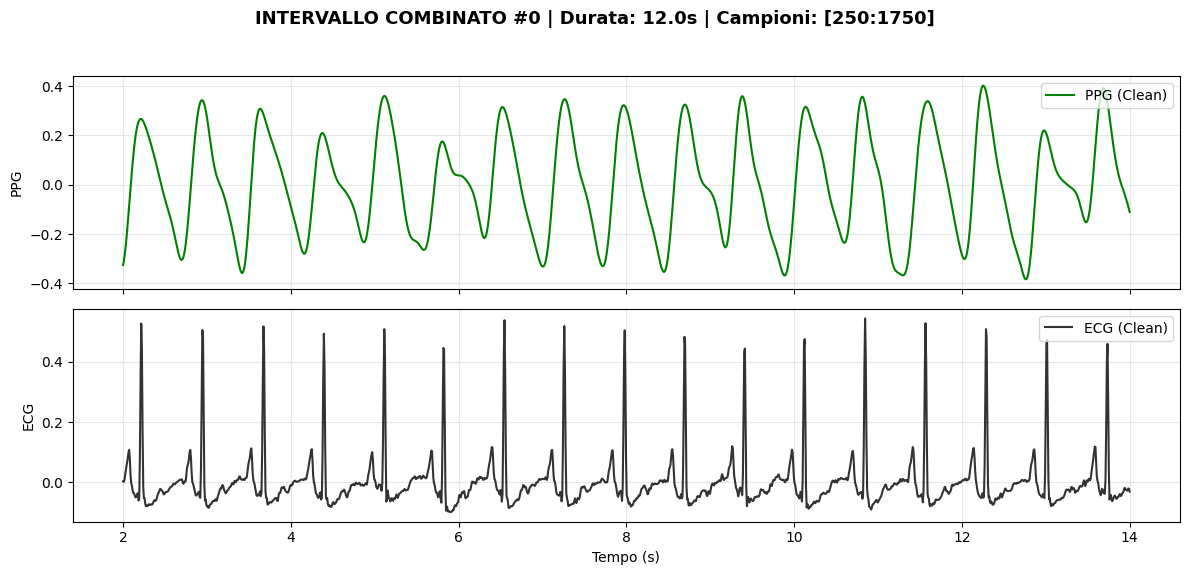

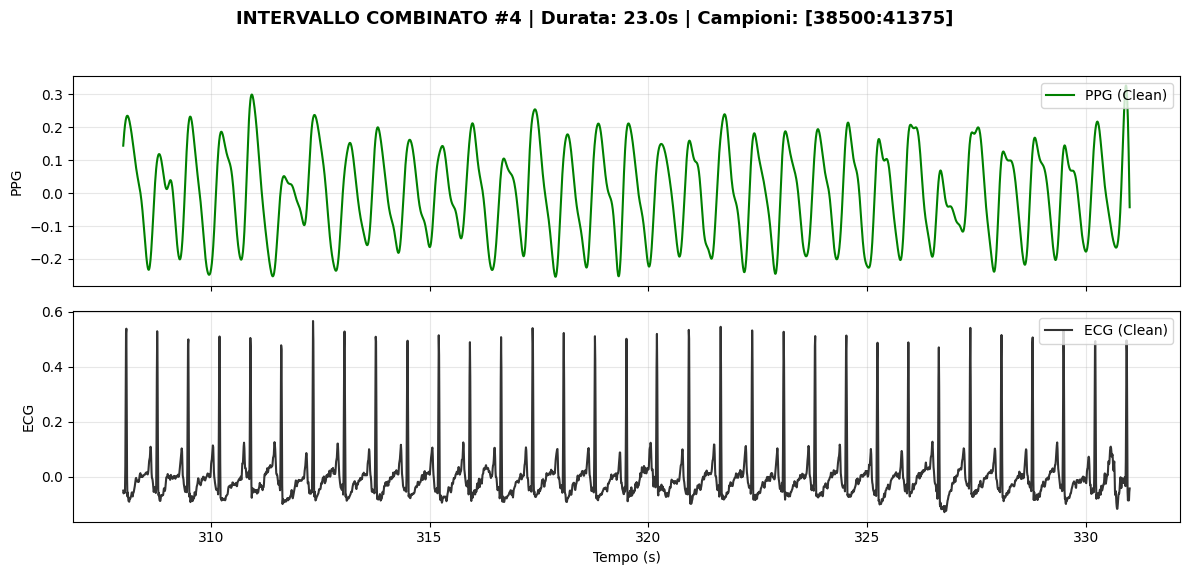

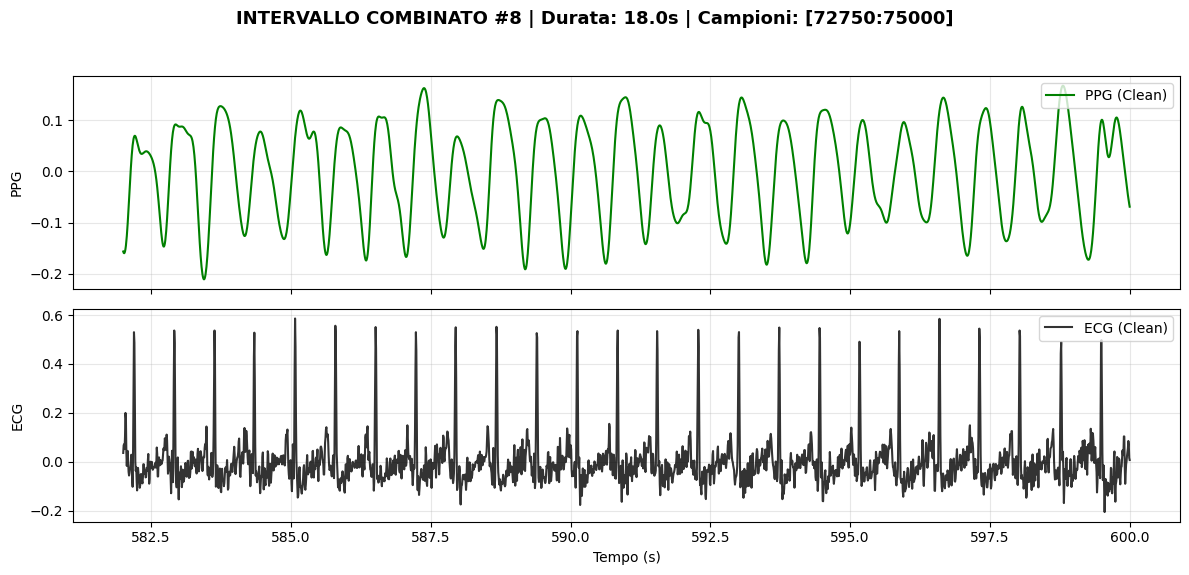

In [27]:

# --- ESECUZIONE ---
WINDOW_SIZE = 4       # Finestra di analisi
SLIDING_STEP = 1
MIN_SIZE = 7          # <--- NUOVO PARAMETRO: Segmenti minimi da 7 secondi
PPG_THRESHOLD = 0.9 
ECG_THRESHOLD = 0.9 

TARGET_DATA = data_p2
LABEL = "Paziente 2"

if TARGET_DATA:
    ppg_i, ecg_i, comb_i = cross_check_analysis(
        TARGET_DATA, 
        win_sec=WINDOW_SIZE, 
        step_sec=SLIDING_STEP,
        min_size_sec=MIN_SIZE, # Passaggio del parametro
        fs=125,
        ppg_thr=PPG_THRESHOLD, 
        ecg_thr=ECG_THRESHOLD
    )
    
    print_cross_stats(TARGET_DATA, ppg_i, ecg_i, comb_i, LABEL)
    
    if len(comb_i) > 0:
        indices = [0, len(comb_i)//2, len(comb_i)-1]
        indices = sorted(list(set(indices)))
        plot_specific_intervals(TARGET_DATA, comb_i, indices)
    else:
        print(f"❌ Nessun intervallo valido > {MIN_SIZE}s trovato.")